# 02: Feature Engineering

## Objectives
1. Create advanced features with business justification
2. Generate sentiment features from synthetic feedback
3. Document feature engineering rationale
4. Prepare data for model training
5. Analyze engineered features

## Feature Categories
- **Tenure Features**: Customer lifecycle phases
- **Charge Features**: Cost analysis and value metrics
- **Service Features**: Service adoption indicators
- **Contract Features**: Commitment and switching cost proxies
- **Composite Features**: Customer value score
- **Sentiment Features**: NLP-based feedback analysis

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

# Import custom modules
from data_loader import load_telco_data
from preprocessing import preprocess_data
from feature_engineering import FeatureEngineer, engineer_features
from sentiment import SentimentAnalyzer, generate_sentiment_features

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
# Load and Preprocess Data
print("=" * 80)
print("LOADING AND PREPROCESSING DATA")
print("=" * 80)

data_path = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

try:
    raw_data = load_telco_data(data_path)
    print("✓ Data loaded")
    
    cleaned_data = preprocess_data(raw_data)
    print("✓ Data cleaned")
    print(f"Data shape: {cleaned_data.shape}")
    
except Exception as e:
    print(f"⚠ Error: {e}")
    print("Please ensure the data file is in data/raw/ directory")

2026-07-12 22:23:35,943 - data_loader - INFO - Data loaded successfully. Shape: (7043, 21)
2026-07-12 22:23:35,944 - data_loader - INFO - Data validation passed
2026-07-12 22:23:35,945 - data_loader - INFO - Data summary:
2026-07-12 22:23:35,953 - data_loader - INFO - Dataset Summary:
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0           0       0              0        0           0       0   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              0                0               0  ...   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   

   PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  Churn  
0                 0              0               0             0      0  

[1 rows x 21 columns]
2026-07-12 22:23:35,954 - data_loader - INFO - {'shape': (7043, 21), 'columns': ['customerID', 'gender', '

LOADING AND PREPROCESSING DATA
✓ Data loaded
✓ Data cleaned
Data shape: (7043, 20)


In [3]:
# Generate Sentiment Features
print("\n" + "=" * 80)
print("SENTIMENT FEATURE ENGINEERING")
print("=" * 80)

sentiment_analyzer = SentimentAnalyzer()

# Generate synthetic feedback
data_with_feedback = sentiment_analyzer.generate_synthetic_feedback(cleaned_data.copy())
print(f"✓ Generated synthetic customer feedback")

# Display sample feedback
print(f"\nSample Customer Feedback:")
for i in range(5):
    print(f"  {i+1}. {data_with_feedback['synthetic_feedback'].iloc[i]}")

# Extract sentiment scores
data_with_sentiment = sentiment_analyzer.extract_sentiment_features(data_with_feedback)
print(f"\n✓ Extracted sentiment scores")

# Sentiment statistics
sentiment_stats = sentiment_analyzer.get_sentiment_statistics(data_with_sentiment)
print(f"\nSentiment Score Statistics:")
for stat, value in sentiment_stats.items():
    print(f"  {stat.capitalize()}: {value:.4f}")

2026-07-12 22:23:36,011 - sentiment - INFO - SentimentAnalyzer initialized with VADER



SENTIMENT FEATURE ENGINEERING


2026-07-12 22:23:37,268 - sentiment - INFO - Generated synthetic feedback for 7043 customers


✓ Generated synthetic customer feedback

Sample Customer Feedback:
  1. Similar to other providers
  2. Average experience so far
  3. Similar to other providers
  4. Decent service overall
  5. Average experience so far


2026-07-12 22:23:37,762 - sentiment - INFO - Extracted sentiment scores
2026-07-12 22:23:37,763 - sentiment - INFO - Sentiment score range: [0.306, 0.879]



✓ Extracted sentiment scores

Sentiment Score Statistics:
  Mean: 0.5288
  Std: 0.1200
  Min: 0.3063
  Max: 0.8790
  Median: 0.5000


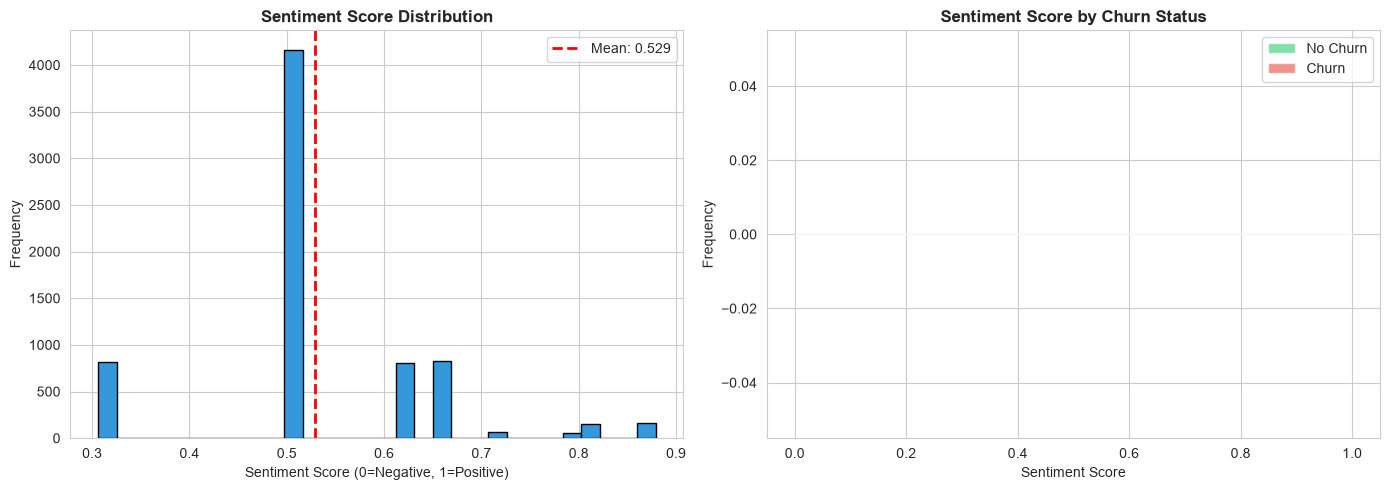

✓ Sentiment analysis visualization saved


In [4]:
# Visualize Sentiment Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(data_with_sentiment['sentiment_score'], bins=30, color='#3498db', edgecolor='black')
axes[0].set_title('Sentiment Score Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Sentiment Score (0=Negative, 1=Positive)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(data_with_sentiment['sentiment_score'].mean(), color='red', 
               linestyle='--', linewidth=2, label=f"Mean: {data_with_sentiment['sentiment_score'].mean():.3f}")
axes[0].legend()

# Sentiment vs Churn
churn_sentiment = pd.DataFrame({
    'Churn': data_with_sentiment['Churn'],
    'Sentiment': data_with_sentiment['sentiment_score']
})

for churn in [0, 1]:
    label = 'Churn' if churn == 1 else 'No Churn'
    color = '#e74c3c' if churn == 1 else '#2ecc71'
    data = churn_sentiment[churn_sentiment['Churn'] == churn]['Sentiment']
    axes[1].hist(data, bins=30, alpha=0.6, label=label, color=color)

axes[1].set_title('Sentiment Score by Churn Status', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/08_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sentiment analysis visualization saved")

In [5]:
# Advanced Feature Engineering
print("\n" + "=" * 80)
print("ADVANCED FEATURE ENGINEERING")
print("=" * 80)

feature_engineer = FeatureEngineer()
engineered_data = feature_engineer.engineer_features(data_with_sentiment.copy())

print(f"✓ Feature engineering complete")
print(f"New shape: {engineered_data.shape}")
print(f"New features created: {engineered_data.shape[1] - cleaned_data.shape[1]}")

# Display feature descriptions
print(f"\nFeature Engineering Summary:")
descriptions = feature_engineer.get_feature_descriptions()
for feature, description in descriptions.items():
    print(f"  • {feature}: {description}")

2026-07-12 22:23:39,237 - feature_engineering - INFO - Starting feature engineering pipeline
2026-07-12 22:23:39,245 - feature_engineering - INFO - Created tenure features
2026-07-12 22:23:39,252 - feature_engineering - INFO - Created charge features
2026-07-12 22:23:39,263 - feature_engineering - INFO - Created service adoption features
2026-07-12 22:23:39,266 - feature_engineering - INFO - Created contract features
2026-07-12 22:23:39,268 - feature_engineering - INFO - Created customer value score
2026-07-12 22:23:39,338 - feature_engineering - INFO - Encoded categorical features
2026-07-12 22:23:39,339 - feature_engineering - INFO - Feature engineering complete. Shape: (7043, 41)
2026-07-12 22:23:39,340 - feature_engineering - INFO - Feature descriptions: ['tenure_phase', 'is_early_phase', 'tenure_normalized', 'charge_per_tenure', 'avg_monthly_value', 'monthly_charge_quartile', 'is_high_charge', 'service_count', 'contract_risk_score', 'is_month_to_month', 'customer_value_score']



ADVANCED FEATURE ENGINEERING
✓ Feature engineering complete
New shape: (7043, 41)
New features created: 21

Feature Engineering Summary:
  • tenure_phase: Customer lifecycle phase
  • is_early_phase: Binary flag for critical first 6 months
  • tenure_normalized: Normalized tenure (0-1)
  • charge_per_tenure: Monthly charges normalized by tenure
  • avg_monthly_value: Average monthly charge value over tenure
  • monthly_charge_quartile: Customer's monthly charge quartile
  • is_high_charge: Flag for high monthly charge customers
  • service_count: Number of services subscribed
  • contract_risk_score: Contract switching cost proxy
  • is_month_to_month: Flag for month-to-month contracts
  • customer_value_score: Composite value score (tenure, revenue, engagement)


In [6]:
# Analyze Engineered Features
print("\n" + "=" * 80)
print("ENGINEERED FEATURES ANALYSIS")
print("=" * 80)

# Tenure Phase Distribution
print("\nTenure Phase Distribution:")
if 'tenure_phase' in engineered_data.columns:
    print(engineered_data['tenure_phase'].value_counts().sort_index())

# Service Count Distribution
print("\nService Count Distribution:")
if 'service_count' in engineered_data.columns:
    print(engineered_data['service_count'].value_counts().sort_values(ascending=False))

# Customer Value Score Statistics
print("\nCustomer Value Score Statistics:")
if 'customer_value_score' in engineered_data.columns:
    print(engineered_data['customer_value_score'].describe())


ENGINEERED FEATURES ANALYSIS

Tenure Phase Distribution:
tenure_phase
0    1024
1     832
2     705
3    3001
4    1481
Name: count, dtype: int64

Service Count Distribution:
service_count
1    2253
4    1062
3    1041
2     996
5     827
6     525
7     259
0      80
Name: count, dtype: int64

Customer Value Score Statistics:
count    7043.000000
mean        0.472450
std         0.243152
min         0.066187
25%         0.268479
50%         0.444986
75%         0.662091
max         1.000000
Name: customer_value_score, dtype: float64


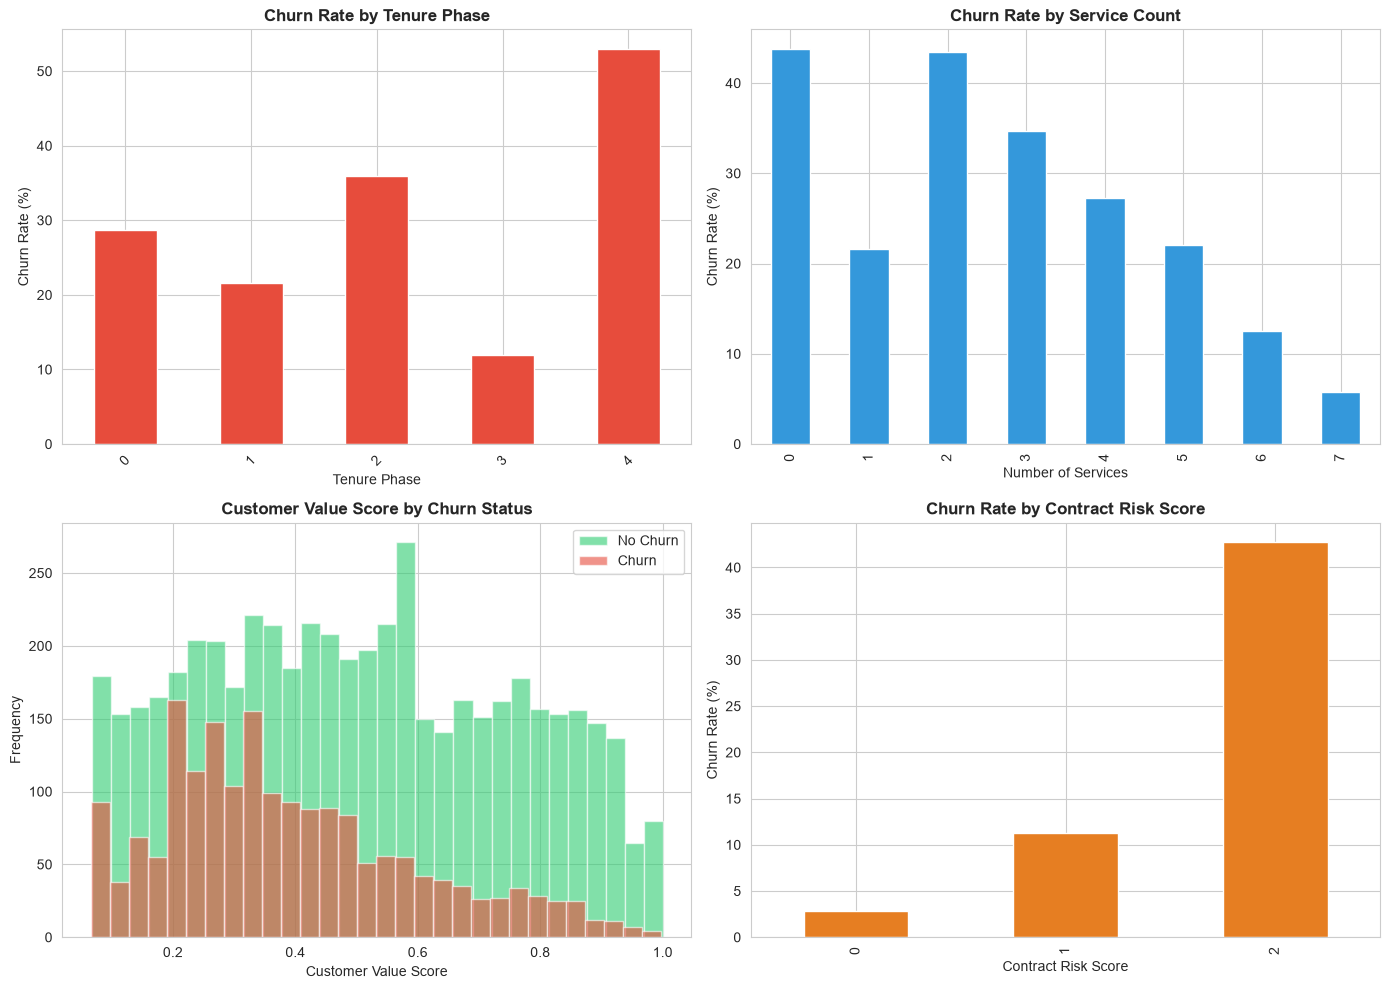

✓ Engineered features impact visualization saved


In [7]:
# Visualize Engineered Features Impact on Churn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tenure Phase vs Churn
if 'tenure_phase' in engineered_data.columns:
    phase_churn = pd.crosstab(engineered_data['tenure_phase'], 
                             engineered_data['Churn'], normalize='index') * 100
    phase_churn[1].plot(kind='bar', ax=axes[0, 0], color='#e74c3c')
    axes[0, 0].set_title('Churn Rate by Tenure Phase', fontweight='bold')
    axes[0, 0].set_xlabel('Tenure Phase')
    axes[0, 0].set_ylabel('Churn Rate (%)')
    axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Service Count vs Churn
if 'service_count' in engineered_data.columns:
    service_churn = pd.crosstab(engineered_data['service_count'], 
                               engineered_data['Churn'], normalize='index') * 100
    service_churn[1].plot(kind='bar', ax=axes[0, 1], color='#3498db')
    axes[0, 1].set_title('Churn Rate by Service Count', fontweight='bold')
    axes[0, 1].set_xlabel('Number of Services')
    axes[0, 1].set_ylabel('Churn Rate (%)')

# 3. Customer Value Score vs Churn
if 'customer_value_score' in engineered_data.columns:
    for churn in [0, 1]:
        label = 'Churn' if churn == 1 else 'No Churn'
        color = '#e74c3c' if churn == 1 else '#2ecc71'
        data = engineered_data[engineered_data['Churn'] == churn]['customer_value_score']
        axes[1, 0].hist(data, bins=30, alpha=0.6, label=label, color=color)
    
    axes[1, 0].set_title('Customer Value Score by Churn Status', fontweight='bold')
    axes[1, 0].set_xlabel('Customer Value Score')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()

# 4. Contract Risk Score vs Churn
if 'contract_risk_score' in engineered_data.columns:
    risk_churn = pd.crosstab(engineered_data['contract_risk_score'], 
                            engineered_data['Churn'], normalize='index') * 100
    risk_churn[1].plot(kind='bar', ax=axes[1, 1], color='#e67e22')
    axes[1, 1].set_title('Churn Rate by Contract Risk Score', fontweight='bold')
    axes[1, 1].set_xlabel('Contract Risk Score')
    axes[1, 1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('../outputs/figures/09_engineered_features_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Engineered features impact visualization saved")


FEATURE CORRELATION ANALYSIS

Top 15 Features Correlated with Churn:
Churn                      1.000000
charge_per_tenure          0.420223
is_month_to_month          0.405103
contract_risk_score        0.396713
is_early_phase             0.308539
monthly_charge_quartile    0.197139
MonthlyCharges             0.193356
PaperlessBilling           0.191825
SeniorCitizen              0.150889
PaymentMethod              0.107062
is_high_charge             0.082833
tenure_phase               0.082026
avg_monthly_value          0.070992
StreamingTV_adopted        0.063228
StreamingMovies_adopted    0.061382
dtype: float64


C:\Users\lenovo\telco-churn-explainability\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\lenovo\telco-churn-explainability\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


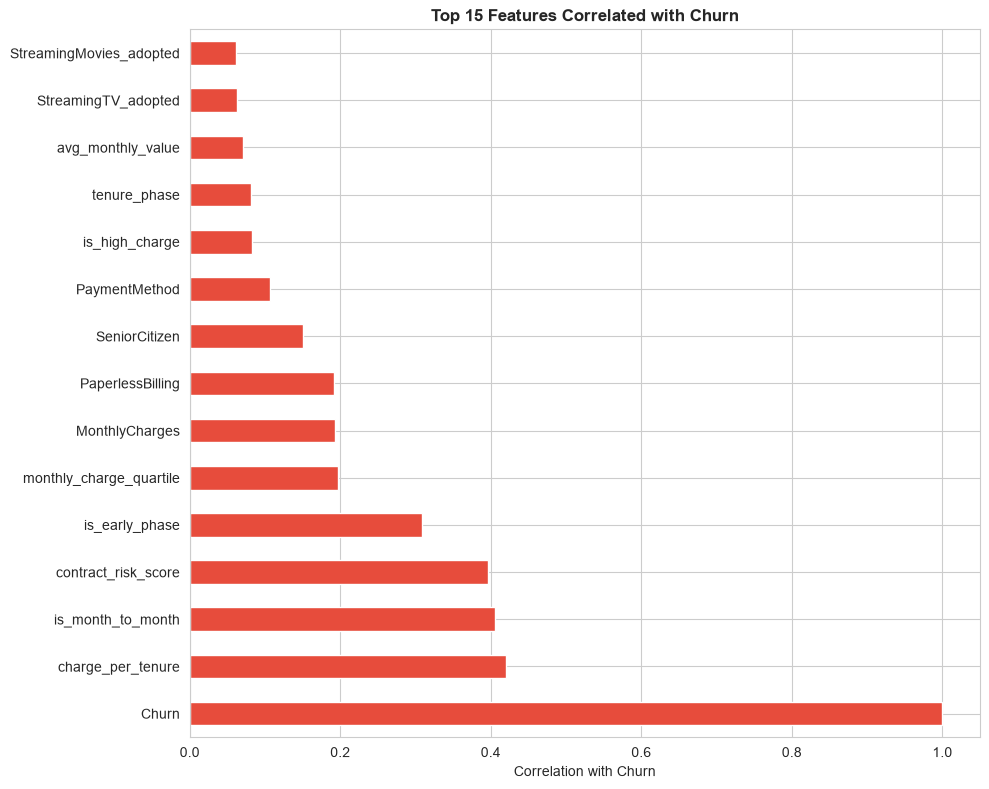

✓ Feature correlation visualization saved


In [8]:
# Feature Correlation with Churn
print("\n" + "=" * 80)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 80)

numeric_engineered = engineered_data.select_dtypes(include=[np.number])
churn_numeric = engineered_data['Churn'].astype(int)
correlations = numeric_engineered.corrwith(churn_numeric).sort_values(ascending=False)

print("\nTop 15 Features Correlated with Churn:")
print(correlations.head(15))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 8))
top_corr = correlations.head(15)
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 15 Features Correlated with Churn', fontweight='bold', fontsize=12)
ax.set_xlabel('Correlation with Churn')
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../outputs/figures/10_feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature correlation visualization saved")

In [9]:
# Save Engineered Dataset
print("\n" + "=" * 80)
print("SAVING ENGINEERED DATA")
print("=" * 80)

output_path = '../data/processed/engineered_data.csv'
engineered_data.to_csv(output_path, index=False)
print(f"✓ Engineered data saved to {output_path}")
print(f"Final dataset shape: {engineered_data.shape}")
print(f"Total features: {engineered_data.shape[1]}")


SAVING ENGINEERED DATA
✓ Engineered data saved to ../data/processed/engineered_data.csv
Final dataset shape: (7043, 41)
Total features: 41


## Feature Engineering Summary

### Created Features

#### Tenure Features
- **tenure_phase**: Customer lifecycle categorization
- **is_early_phase**: Binary flag for high-risk first 6 months
- **tenure_normalized**: 0-1 scaled tenure

#### Charge Features
- **charge_per_tenure**: Monthly charges normalized by tenure
- **avg_monthly_value**: Average monthly spending over customer lifetime
- **monthly_charge_quartile**: Customer's spending quartile
- **is_high_charge**: Flag for top 25% spenders

#### Service Features
- **service_count**: Total number of adopted services
- **[Service]_adopted**: Binary flags for each service

#### Contract Features
- **contract_risk_score**: Proxy for switching costs (0.2-1.0)
- **is_month_to_month**: Binary flag for month-to-month contracts

#### Composite Features
- **customer_value_score**: Weighted composite (50% tenure, 30% revenue, 20% engagement)

#### Sentiment Features
- **synthetic_feedback**: Synthetic customer feedback
- **sentiment_score**: VADER sentiment analysis (0-1 range)

### Business Justification
1. **Tenure Phase** captures customer lifecycle risk
2. **Service Count** increases switching costs
3. **Contract Risk** directly measures commitment level
4. **Customer Value Score** identifies high-value customers
5. **Sentiment Score** captures customer satisfaction level

### Key Insights
- Service adoption strongly reduces churn risk
- Longer contracts show dramatic churn reduction
- Early-phase customers need retention focus
- Sentiment scores provide independent signal